## This is the Notebook to compare fmg & gather & mapping results

- gather_ref_f_weighted → standard gather result (k31, used to select genomes)
- ref_f_weighted → FMG (fastmulti-gather) result (k31)
- f_mapped_reads → genome-grist read mapping result

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 1) read files
gather = pd.read_csv("../../data/gather_ref_f_weighted.tsv", sep="\t")
mapped  = pd.read_csv("../../data/f_mapped_reads.csv")
fmg  = pd.read_csv("../../data/fmg_r226_k31_biome.csv")

# rename column to match others
mapped = mapped.rename(columns={"sample_id": "accession"})
fmg  = fmg.rename(columns={"ref_f_weighted":"fmg_ref_f_weighted"})

# 2) merge on accession
merged = (
    gather
    .merge(mapped, on="accession", how="inner")
    .merge(fmg, on="accession", how="inner")
)

# 3) keep only requested columns (in your preferred order)
keep = [
    "accession",
    "gather_ref_f_weighted",
    "fmg_ref_f_weighted",
    "f_mapped_reads",
    "biome3",
    "total_mapped_reads",
    "total_n_reads",
    "n_matches",
]
merged = merged[keep]

# 4) display + save
merged.head()

,accession,gather_ref_f_weighted,fmg_ref_f_weighted,f_mapped_reads,biome3,total_mapped_reads,total_n_reads,n_matches
0,DRR014782,0.868853,0.911885,0.905193,Host-associated:Mammals:Respiratory system,75612507,83531900,3721
1,DRR014785,0.863483,0.911224,0.904628,Host-associated:Mammals:Respiratory system,83163638,91931356,4159
2,DRR121397,0.153467,0.238478,0.371231,Host-associated:Plants:Root,2121643,5715162,3533
3,DRR121401,0.107862,0.183724,0.288395,Host-associated:Plants:Root,1311236,4546672,3031
4,ERR10695318,0.748644,0.797516,0.859269,Engineered:Food production:Dairy products,123175020,143348680,535


In [3]:
# merged.to_csv("../results/gather_fmg_grist_k31.csv",index=False)

In [4]:
df = pd.read_csv("../../data/gather_fmg_grist_k31.csv")
df

,accession,gather_ref_f_weighted,fmg_ref_f_weighted,f_mapped_reads,biome3,total_mapped_reads,total_n_reads,n_matches
0,DRR014782,0.868853,0.911885,0.905193,Host-associated:Mammals:Respiratory system,75612507,83531900,3721
1,DRR014785,0.863483,0.911224,0.904628,Host-associated:Mammals:Respiratory system,83163638,91931356,4159
2,DRR121397,0.153467,0.238478,0.371231,Host-associated:Plants:Root,2121643,5715162,3533
3,DRR121401,0.107862,0.183724,0.288395,Host-associated:Plants:Root,1311236,4546672,3031
4,ERR10695318,0.748644,0.797516,0.859269,Engineered:Food production:Dairy products,123175020,143348680,535
...,...,...,...,...,...,...,...,...
77,SRR6765262,0.405779,0.528815,0.762911,Host-associated:Birds:Digestive system,1518088,1989862,2021
78,SRR7299214,0.289706,0.350863,0.403080,Engineered:Solid waste:Landfill,6705137,16634768,3762
79,SRR7610133,0.289630,0.296219,0.510271,Host-associated:Fish:Digestive system,3058996,5994846,509
80,SRR9109404,0.612335,0.628079,0.646912,Host-associated:Fish:Digestive system,25075735,38762198,1110


In [5]:
# sanity check
df.shape, df["accession"].nunique()

((82, 8), 82)

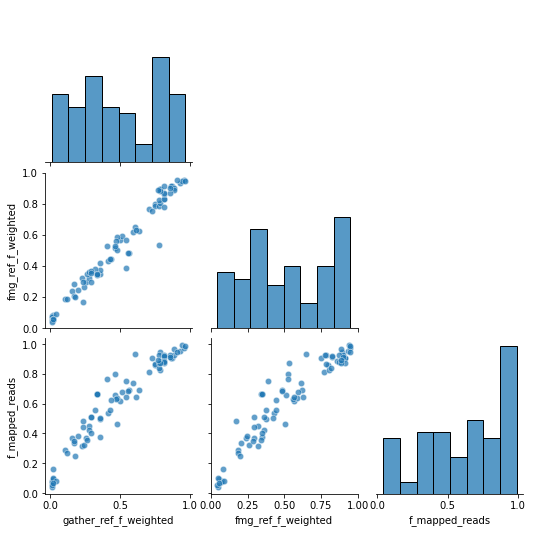

In [6]:
g = sns.pairplot(
    df,
    vars=["gather_ref_f_weighted", "fmg_ref_f_weighted", "f_mapped_reads"],
    corner=True,
    plot_kws={"alpha": 0.7, "s": 40}
)

# set axis limits for ref_f_weighted
for i, yvar in enumerate(g.y_vars):
    for j, xvar in enumerate(g.x_vars):
        ax = g.axes[i, j]
        if ax is None:
            continue
        if xvar == "fmg_ref_f_weighted":
            ax.set_xlim(0, 1.0)
        if yvar == "fmg_ref_f_weighted":
            ax.set_ylim(0, 1.0)

plt.show()

### color-code biome

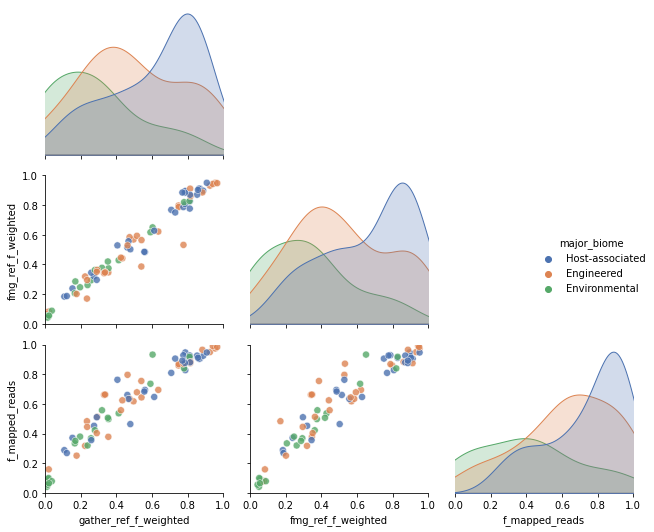

In [7]:
df = pd.read_csv("../../data/gather_fmg_grist_k31.csv")

# Extract major biome category
df["major_biome"] = df["biome3"].str.split(":", n=1).str[0]

# Keep only the three main categories (defensive)
keep = ["Host-associated", "Engineered", "Environmental"]
df = df[df["major_biome"].isin(keep)].copy()

# Define consistent color palette
palette = {
    "Host-associated": "#4C72B0",   # blue
    "Engineered": "#DD8452",        # orange
    "Environmental": "#55A868"      # green
}

# Pairplot with biome coloring
g = sns.pairplot(
    df,
    vars=["gather_ref_f_weighted", "fmg_ref_f_weighted", "f_mapped_reads"],
    hue="major_biome",
    palette=palette,
    corner=True,
    plot_kws={"alpha": 0.8, "s": 50}
)

# Set consistent axis limits
for i, yvar in enumerate(g.y_vars):
    for j, xvar in enumerate(g.x_vars):
        ax = g.axes[i, j]
        if ax is None:
            continue
        ax.set_xlim(0, 1.0)
        ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

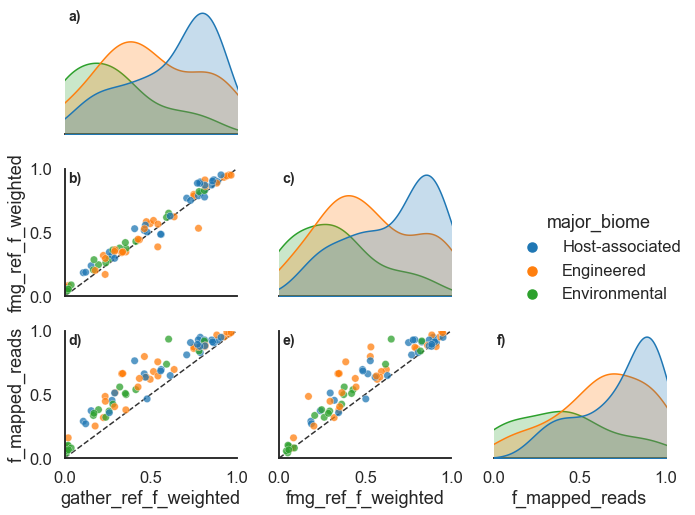

In [8]:
df["major_biome"] = df["biome3"].astype(str).str.split(":", n=1).str[0]

# Keep only expected categories (defensive)
keep = ["Host-associated", "Engineered", "Environmental"]
df = df[df["major_biome"].isin(keep)].copy()

# Order + palette (matches your thesis theme: blue/orange/green)
hue_order = ["Host-associated", "Engineered", "Environmental"]
palette = {
    "Host-associated": "#1f77b4",  # blue
    "Engineered": "#ff7f0e",       # orange
    "Environmental": "#2ca02c"     # green
}

# -------------------------
# Pairplot: KDE on diagonal, scatter on lower triangle
# -------------------------
sns.set(style="white", context="talk")

g = sns.pairplot(
    df,
    vars=["gather_ref_f_weighted", "fmg_ref_f_weighted", "f_mapped_reads"],
    hue="major_biome",
    hue_order=hue_order,
    palette=palette,
    corner=True,
    diag_kind="kde",
    plot_kws={"alpha": 0.75, "s": 55, "edgecolor": "white", "linewidth": 0.4},
    diag_kws={"fill": True, "alpha": 0.25}
)

# -------------------------
# Force axes to 0..1 and add ONE 1:1 line per lower panel
# -------------------------
for i, yvar in enumerate(g.y_vars):
    for j, xvar in enumerate(g.x_vars):
        ax = g.axes[i, j]
        if ax is None:
            continue

        # Consistent limits (all metrics are fractions)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        # Only lower triangle plots exist when corner=True, but keep the guard anyway
        if i > j:
            ax.plot(
                [0, 1], [0, 1],
                linestyle="--",
                color="black",
                linewidth=1.5,
                alpha=0.8,
                zorder=0
            )

# Tidy legend (keeps colored markers)
if g._legend is not None:
    g._legend.set_title("major_biome")

# -------------------------
# Add panel labels (a, b, c, ...)
# -------------------------
import string

letters = list(string.ascii_lowercase)
label_idx = 0

for i in range(len(g.axes)):
    for j in range(len(g.axes[i])):
        ax = g.axes[i, j]
        if ax is None:
            continue

        ax.text(
            0.02, 0.98,
            f"{letters[label_idx]})",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=14,
            fontweight="bold"
        )
        label_idx += 1

plt.tight_layout()
plt.show()

Engineered           32
Animal-associated    26
Environmental        20
Plant-associated      5
Name: biome_split, dtype: int64


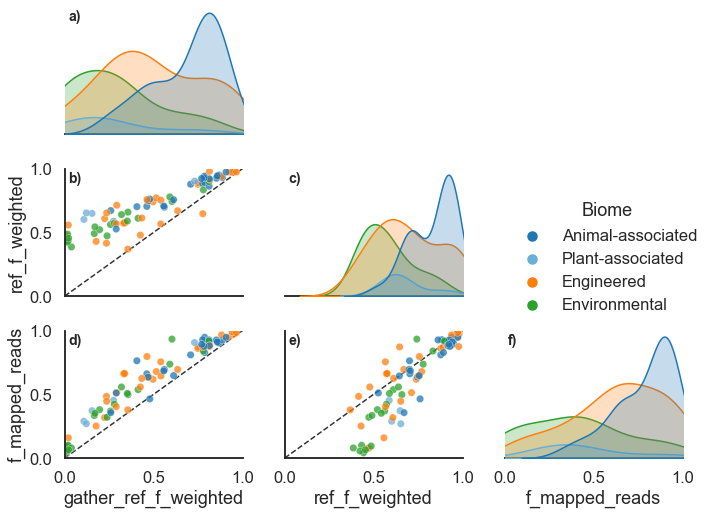

In [11]:
# split Host-associated → Animal vs Plan
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string

# -------------------------
# Load data
# -------------------------
df = pd.read_csv("../../data/gather_fmg_grist_k31_w_biome1.csv")

# -------------------------
# Use correct biome level
# -------------------------
df["major_biome"] = df["biome1"]

# -------------------------
# Define plant vs animal (robust keywords)
# -------------------------
plant_keywords = [
    "plant", "root", "rhizo", "phyllo", "soil plant"
]

# Create split column
df["biome_split"] = df["major_biome"]

mask_host = df["major_biome"] == "Host-associated"

is_plant = (
    df["biome2"].str.contains("|".join(plant_keywords), case=False, na=False) |
    df["biome3"].str.contains("|".join(plant_keywords), case=False, na=False)
)

df.loc[mask_host & is_plant, "biome_split"] = "Plant-associated"
df.loc[mask_host & ~is_plant, "biome_split"] = "Animal-associated"

# -------------------------
# Keep only categories we want
# -------------------------
keep = ["Animal-associated", "Plant-associated", "Engineered", "Environmental"]
df = df[df["biome_split"].isin(keep)].copy()

# -------------------------
# DEBUG (very important)
# -------------------------
print(df["biome_split"].value_counts())

# -------------------------
# Plot settings
# -------------------------
hue_order = ["Animal-associated", "Plant-associated", "Engineered", "Environmental"]

palette = {
    "Animal-associated": "#1f77b4",   # blue
    "Plant-associated": "#6baed6",    # light blue
    "Engineered": "#ff7f0e",          # orange
    "Environmental": "#2ca02c"        # green
}

sns.set(style="white", context="talk")

# -------------------------
# Pairplot
# -------------------------
g = sns.pairplot(
    df,
    vars=["gather_ref_f_weighted", "ref_f_weighted", "f_mapped_reads"],
    hue="biome_split",
    hue_order=hue_order,
    palette=palette,
    corner=True,
    diag_kind="kde",
    plot_kws={"alpha": 0.75, "s": 55, "edgecolor": "white", "linewidth": 0.4},
    diag_kws={"fill": True, "alpha": 0.25}
)

# -------------------------
# Axis limits + 1:1 lines
# -------------------------
for i, yvar in enumerate(g.y_vars):
    for j, xvar in enumerate(g.x_vars):
        ax = g.axes[i, j]
        if ax is None:
            continue

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        if i > j:
            ax.plot([0, 1], [0, 1],
                    linestyle="--",
                    color="black",
                    linewidth=1.5,
                    alpha=0.8,
                    zorder=0)

# -------------------------
# Legend
# -------------------------
if g._legend is not None:
    g._legend.set_title("Biome")

# -------------------------
# Panel labels
# -------------------------
letters = list(string.ascii_lowercase)
label_idx = 0

for i in range(len(g.axes)):
    for j in range(len(g.axes[i])):
        ax = g.axes[i, j]
        if ax is None:
            continue

        ax.text(
            0.02, 0.98,
            f"{letters[label_idx]})",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=14,
            fontweight="bold"
        )
        label_idx += 1

plt.tight_layout()
plt.show()